In [1]:
import pandas as pd
import os

import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"]  = 300
plt.style.use('dark_background')
plt.rcParams.update({'font.size': 10})

In [2]:
hydro_path = '/media/iielse/T9/CAMELS-FI/data/CAMELS_FI_hydrologic_attributes.csv'
hydro = pd.read_csv(hydro_path)
hydro = hydro.set_index('gauge_id')

clim_path = '/media/iielse/T9/CAMELS-FI/data/CAMELS_FI_climatic_attributes.csv'
clim = pd.read_csv(clim_path)
clim = clim.set_index('gauge_id')

meta_path = '/media/iielse/T9/CAMELS-FI/data/CAMELS_FI_meta_attributes.csv'
meta = pd.read_csv(meta_path)
meta = meta.set_index('gauge_id')

In [3]:
hydro

,timeseries_number_of_years,sign_start_date,sign_end_date,sign_number_of_years,sign_number_of_obs,q_mean,runoff_ratio,stream_elas,slope_fdc,baseflow_index_ladson,baseflow_index_lfstat,hfd_mean,Q5,Q95,high_q_freq,high_q_dur,low_q_freq,low_q_dur,zero_q_freq
gauge_id,,,,,,,,,,,,,,,,,,,
896,46.00,1990-09-01,2020-08-31,30.00,10958,0.83,0.45,1.10,1.55,0.80,0.95,210.23,0.33,1.75,0.00,0.00,0.00,0.00,0.00
905,49.96,1990-09-01,2020-08-31,29.96,10944,1.04,0.52,1.08,2.96,0.57,0.62,234.70,0.17,3.71,9.31,9.62,35.11,28.43,0.00
907,47.95,1990-09-01,2020-08-31,29.95,10941,1.11,0.60,0.96,2.97,0.49,0.50,237.07,0.15,4.19,15.96,6.64,67.00,28.67,0.00
908,30.91,1993-01-01,2020-08-31,27.58,10072,0.98,0.55,1.04,2.87,0.44,0.36,227.14,0.00,3.78,14.03,9.44,86.42,2.68,0.13
923,45.00,1990-09-01,2020-08-31,30.00,10958,1.34,0.68,0.90,2.94,0.52,0.57,218.63,0.13,5.02,11.90,6.74,61.20,23.54,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3727,5.81,2018-03-06,2023-12-31,5.81,2121,0.17,0.10,-0.35,0.81,0.83,0.88,195.17,0.10,0.23,0.00,0.00,0.00,0.00,0.00
3728,5.77,2018-03-06,2023-12-31,5.77,2107,2.16,1.27,0.73,1.64,0.74,0.81,200.33,0.23,4.42,0.00,0.00,32.20,3.98,0.02
3850,8.12,2015-11-13,2023-12-31,8.12,2965,1.08,0.69,0.84,1.73,0.64,0.64,185.25,0.32,3.18,0.90,3.50,5.01,6.50,0.00


In [4]:
clim

,p_mean,pet_mean,temperature_mean,aridity,p_seasonality,frac_snow,high_prec_freq,high_prec_dur,high_prec_timing,low_prec_freq,low_prec_dur,low_prec_timing
gauge_id,,,,,,,,,,,,
896,1.85,1.52,3.62,0.82,0.23,0.27,15.70,1.16,jja,229.02,3.92,mam
905,1.98,1.29,2.54,0.65,0.23,0.30,14.43,1.15,jja,221.29,3.56,mam
907,1.84,1.25,2.62,0.68,0.28,0.29,15.67,1.14,jja,228.12,3.81,mam
908,1.81,1.25,2.66,0.69,0.27,0.29,15.43,1.12,jja,229.16,3.86,mam
923,1.97,1.42,2.97,0.72,0.22,0.30,15.17,1.10,jja,220.36,3.71,mam
...,...,...,...,...,...,...,...,...,...,...,...,...
3727,1.70,1.15,1.30,0.68,0.27,0.34,16.20,1.15,jja,235.29,3.90,mam
3728,1.69,1.14,1.28,0.67,0.27,0.34,16.57,1.15,jja,236.59,3.94,mam
3850,1.75,1.88,4.74,1.08,0.20,0.24,16.63,1.20,jja,237.36,4.21,NaN


In [5]:
# Budyko curve is created by plotting Aridity (PE / P) compared to Runoff coefficient (Q/P)
hydroclim = clim.join([hydro, meta[['water_region_name', 'water_region_code']]])
hydroclim
bud = hydroclim[['p_mean', 'pet_mean', 'q_mean', 'water_region_name', 'water_region_code']].copy()
bud['aridity'] = bud.pet_mean / bud.p_mean
bud['runoff_coef'] = bud.q_mean / bud.p_mean
bud['aet_mean'] = bud.p_mean - bud.q_mean
bud['evaporative_index'] = bud.aet_mean / bud.pet_mean
bud['rgb'] = bud['water_region_code'].map({2:'#4ca9ff', 1:'#11548a', 3:'#ffffff'})
bud

,p_mean,pet_mean,q_mean,water_region_name,water_region_code,aridity,runoff_coef,aet_mean,evaporative_index,rgb
gauge_id,,,,,,,,,,
896,1.85,1.52,0.83,Lakes,2,0.821622,0.448649,1.02,0.671053,#4ca9ff
905,1.98,1.29,1.04,Lakes,2,0.651515,0.525253,0.94,0.728682,#4ca9ff
907,1.84,1.25,1.11,Lakes,2,0.679348,0.603261,0.73,0.584000,#4ca9ff
908,1.81,1.25,0.98,Lakes,2,0.690608,0.541436,0.83,0.664000,#4ca9ff
923,1.97,1.42,1.34,Lakes,2,0.720812,0.680203,0.63,0.443662,#4ca9ff
...,...,...,...,...,...,...,...,...,...,...
3727,1.70,1.15,0.17,Lapland,3,0.676471,0.100000,1.53,1.330435,#ffffff
3728,1.69,1.14,2.16,Lapland,3,0.674556,1.278107,-0.47,-0.412281,#ffffff
3850,1.75,1.88,1.08,Coast,1,1.074286,0.617143,0.67,0.356383,#11548a


# budyko

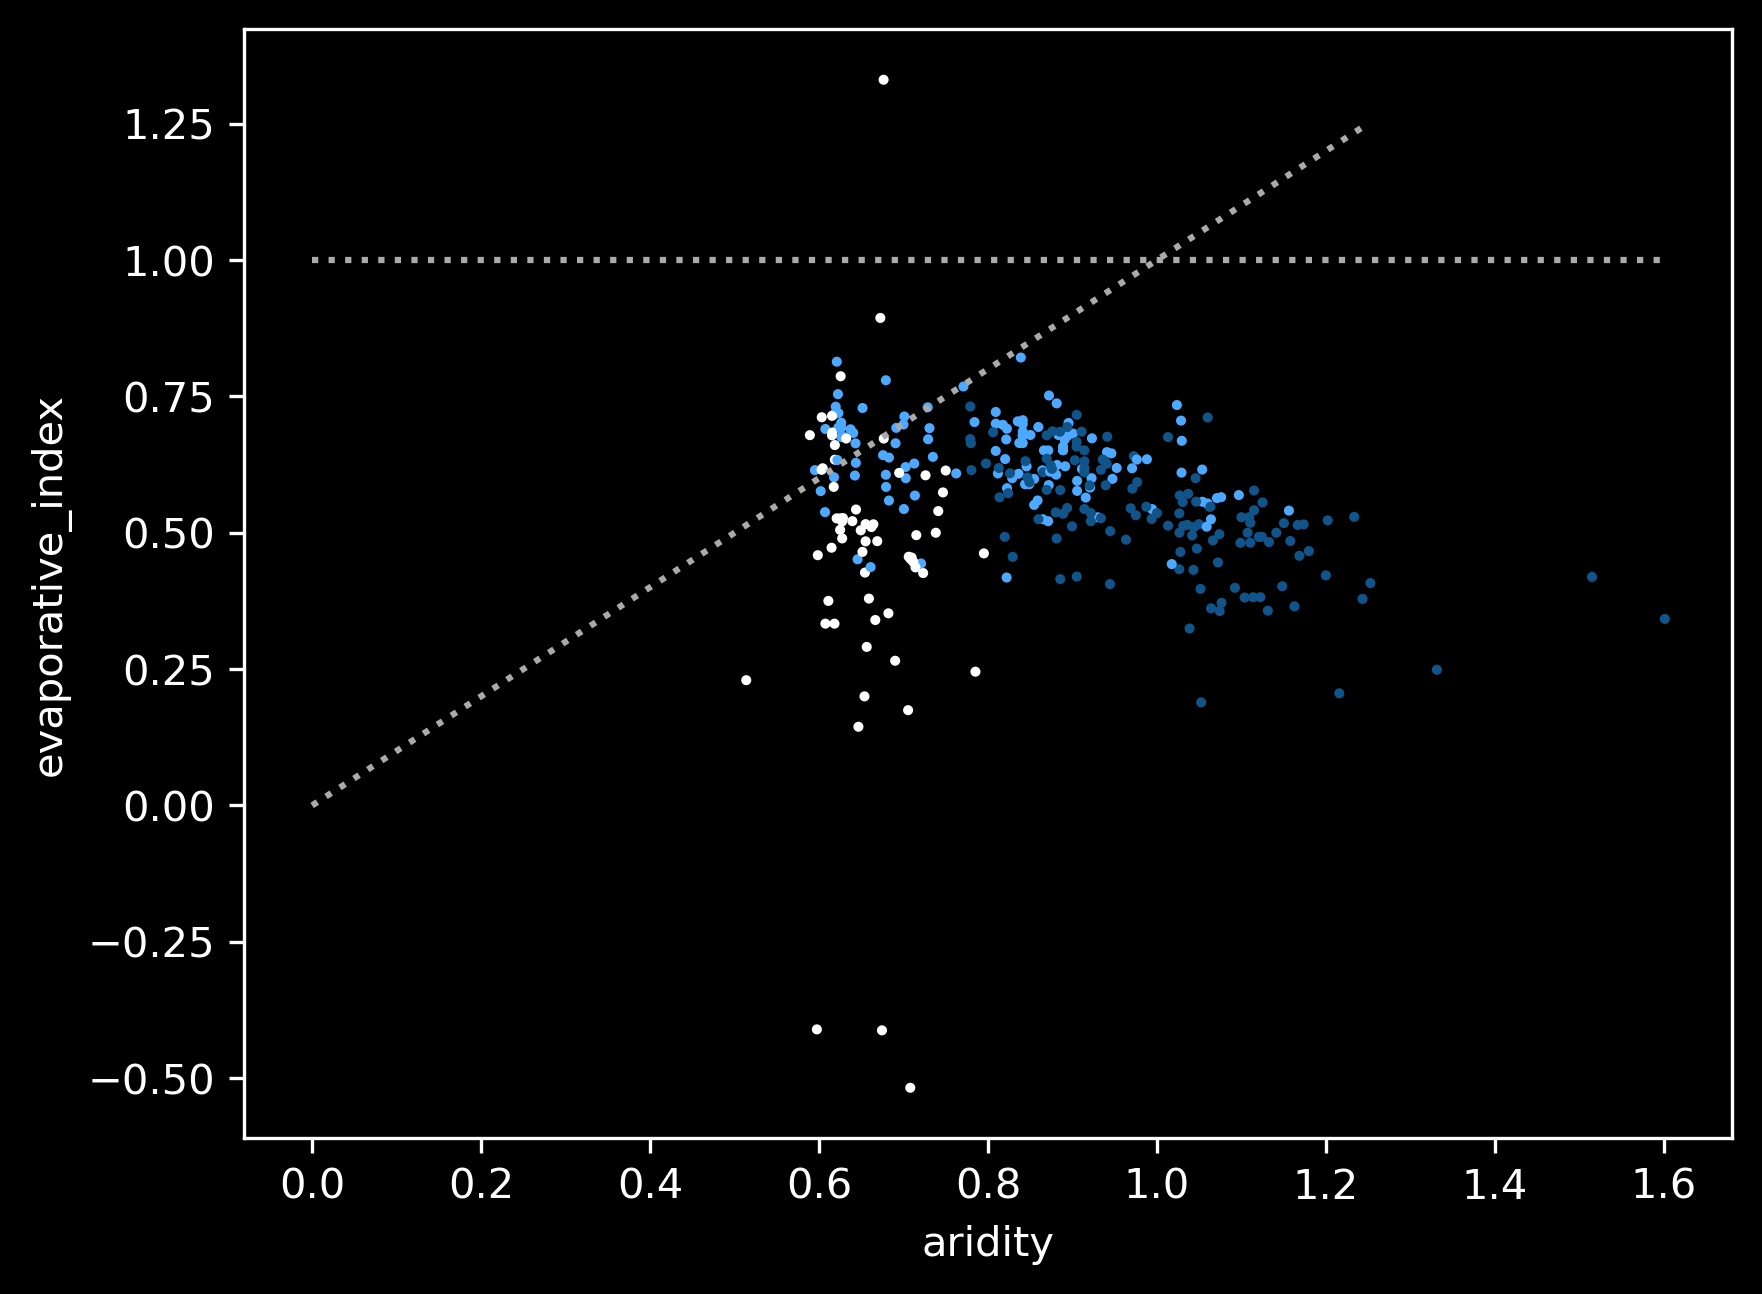

In [6]:
lines = [
    ((0, 1), (1.6, 1)), 
    ((0, 0), (1.25, 1.25))
]
ax = bud.plot(x='aridity', y='evaporative_index', s=2, c='rgb', kind='scatter')

for (x1, y1), (x2, y2) in lines:
    lines = plt.plot([x1, x2], [y1, y2], ':', c='#aaaaaa')

# aridity vs runoff coef

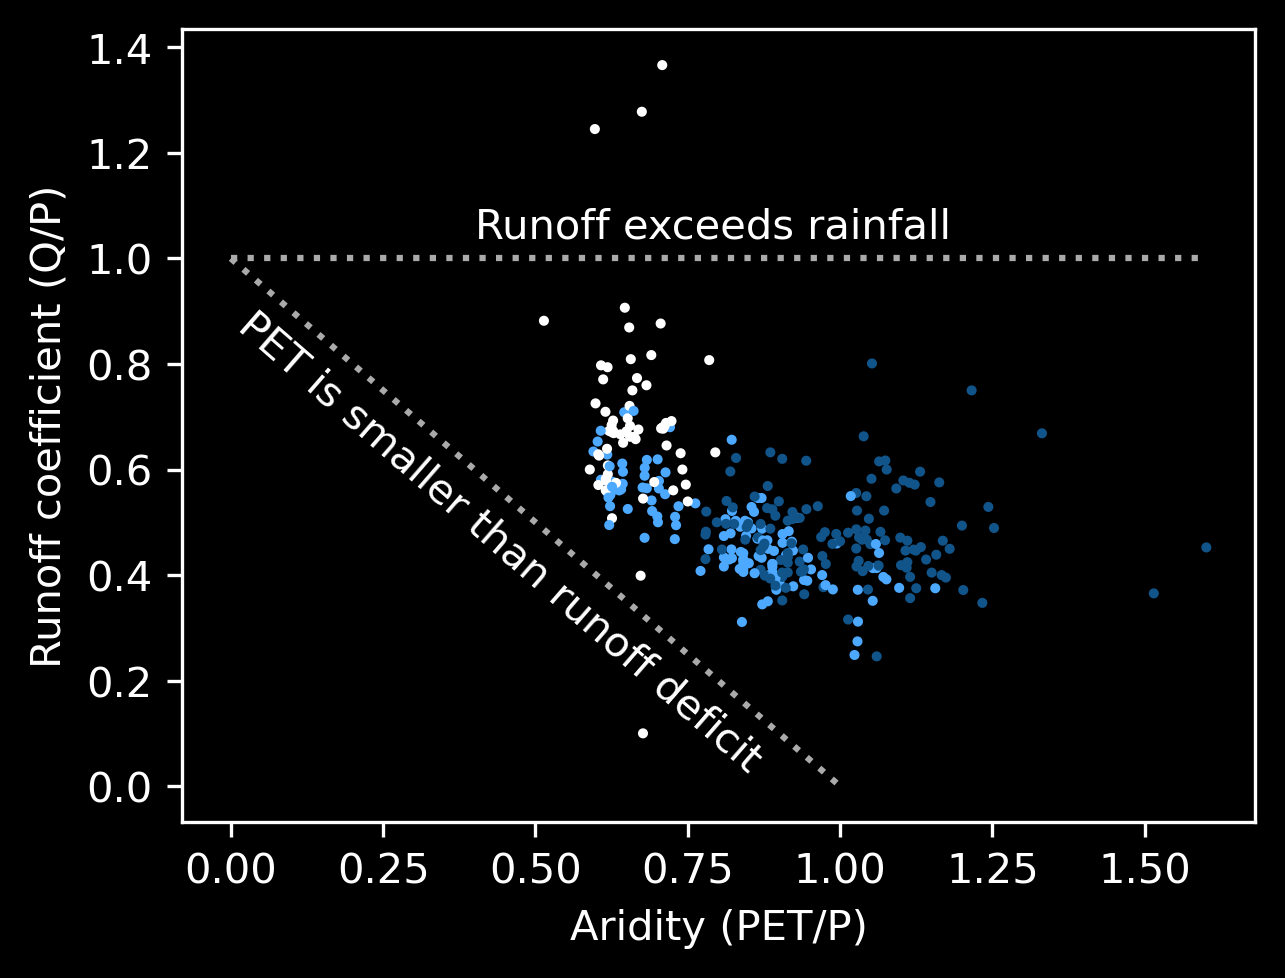

In [7]:
# used to convert cm to inches
cm_conversion = 1 / 2.54

width = 11.5
height = 8.5
lines = [
    ((0, 1), (1, 0)), 
    ((0, 1), (1.6, 1))
]
ax = bud.plot(
    x='aridity', y='runoff_coef', s=2,
    c='rgb', kind='scatter', 
    figsize=(width*cm_conversion, height*cm_conversion))
ax.set_xlabel('Aridity (PET/P)')
ax.set_ylabel('Runoff coefficient (Q/P)')

ax.text(0.4, 1.04, 'Runoff exceeds rainfall')
ax.text(0.0, 0.03, 'PET is smaller than runoff deficit', rotation=-41)

for (x1, y1), (x2, y2) in lines:
    lines = plt.plot([x1, x2], [y1, y2], ':', c='#aaaaaa')
plt.subplots_adjust(left=0.2, right=0.99,
    top=0.99, bottom=0.2)
#plt.savefig('CAMELS-FI/figures/aridity_vs_runoff_coef.png', transparent=True)

In [13]:
bud[bud.runoff_coef > 1]

,p_mean,pet_mean,q_mean,water_region_name,water_region_code,aridity,runoff_coef,aet_mean,evaporative_index,rgb
gauge_id,,,,,,,,,,
1369,1.61,1.14,2.20,Lapland,3,0.708075,1.366460,-0.59,-0.517544,#ffffff
3335,1.59,0.95,1.98,Lapland,3,0.597484,1.245283,-0.39,-0.410526,#ffffff
3728,1.69,1.14,2.16,Lapland,3,0.674556,1.278107,-0.47,-0.412281,#ffffff


In [15]:
bud[bud.runoff_coef < 0.2]

,p_mean,pet_mean,q_mean,water_region_name,water_region_code,aridity,runoff_coef,aet_mean,evaporative_index,rgb
gauge_id,,,,,,,,,,
3727,1.7,1.15,0.17,Lapland,3,0.676471,0.1,1.53,1.330435,#ffffff


In [8]:
bud[bud.aridity > 1.5]

,p_mean,pet_mean,q_mean,water_region_name,water_region_code,aridity,runoff_coef,aet_mean,evaporative_index,rgb
gauge_id,,,,,,,,,,
1120,1.68,2.69,0.76,Coast,1,1.60119,0.452381,0.92,0.342007,#11548a
1122,1.67,2.53,0.61,Coast,1,1.51497,0.365269,1.06,0.418972,#11548a
